# Simple Plotting


In [1]:
# Setup Paths and Target Models
RESULTS_PATH = "/Users/sunil/My Files/TARA/Final Project/weak_to_strong_generalization/results"
PLOT_ALL_SEEDS = False

# Modified to include both short and long organization names to match the specific run logs
MODELS_TO_PLOT = ["Qwen/Qwen2.5-0.5B", "meta-llama/Llama-3.2-3B", "Qwen2.5-0.5B", "Llama-3.2-3B"]

In [2]:
# Preview Dataset Contents: Loads a tiny slice of the SciQ training split to inspect the exact question-answering formatting.
%pip install datasets
from datasets import load_dataset

print("🔄 Fetching a preview slice of the 'sciq' dataset...")
preview_ds = load_dataset("sciq", split="train[:5]")

# Convert the dataset to a pandas DataFrame for a clean, clean tabular render
preview_df = pd.DataFrame(preview_ds)

# Re-order columns slightly to put the core text up front
cols_to_show = ['question', 'correct_answer', 'distractor1', 'distractor2', 'distractor3', 'support']
display(preview_df[cols_to_show])


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔄 Fetching a preview slice of the 'sciq' dataset...


HfUriError: Invalid HF URI 'hf://datasets/sciq@2c94ad3e1aafab77146f384e23536f97a4849815/.huggingface.yaml'. Repository id must be 'namespace/name', got 'sciq'.

In [7]:
%pip install numpy pandas matplotlib seaborn

  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.9-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-macosx_10_9_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
Using cached pandas-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (9.9 MB)
Using cached matplotlib-3.10.9-cp311-cp311-macosx_11_0_arm64.whl (8.2 MB)
Using cached se

In [21]:
# Import Visualization Libraries: Loads numerical computing libraries, data management structures, and plotting engines with explicit display configurations.
# Import Visualization Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from IPython.display import display
import os
import glob
import json

In [22]:
# Load and Parse Results JSONs
records = []
for result_filename in glob.glob(os.path.join(RESULTS_PATH, "**/results_summary.json"), recursive=True):
    # Using os.path.dirname to handle absolute path string compilation safely
    config_file = os.path.join(os.path.dirname(result_filename), "config.json")
    if not os.path.exists(config_file):
        continue
        
    config = json.load(open(config_file, "r"))
    if config["model_size"] not in MODELS_TO_PLOT:
        continue
    if 'seed' not in config:
        config['seed'] = 0
    record = config.copy()
    if 'weak_model' in config:
        for k in record['weak_model']:
            if k == 'model_size':
                assert record['weak_model'][k] == record['weak_model_size']
            record['weak_' + k] = record['weak_model'][k]
        del record['weak_model']
    record.update(json.load(open(result_filename)))
    
    # Standardize namespaces to short names to ensure lookup alignment in the next cell
    if 'model_size' in record and isinstance(record['model_size'], str):
        record['model_size'] = record['model_size'].split('/')[-1]
    if 'weak_model_size' in record and isinstance(record['weak_model_size'], str):
        record['weak_model_size'] = record['weak_model_size'].split('/')[-1]
        
    records.append(record)

df = pd.DataFrame.from_records(records).sort_values(['ds_name', 'model_size'])

Dataset: sciq (seed: None)


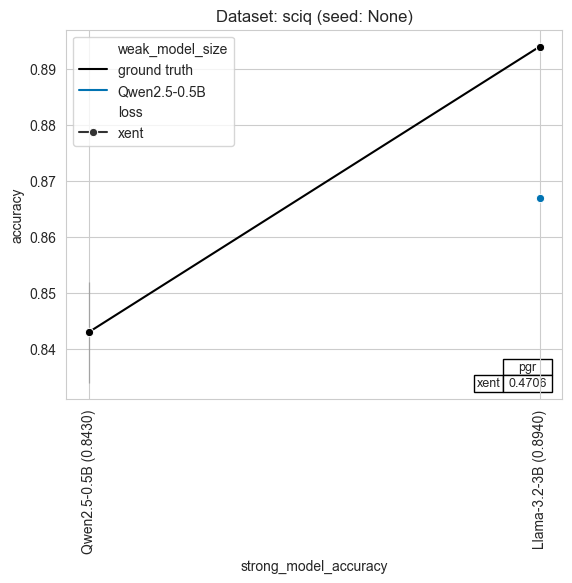

In [23]:
# Compute Metrics and Render Curves
datasets = df.ds_name.unique()
for dataset in datasets:
    cur_df = df[(df.ds_name == dataset)].copy()
    base_accuracies = cur_df[cur_df['weak_model_size'].isna()].groupby('model_size').agg({'accuracy': 'mean', 'seed': 'count'}).sort_values('accuracy')
    base_accuracy_lookup = base_accuracies['accuracy'].to_dict()
    base_accuracies = base_accuracies.reset_index()

    cur_df['strong_model_accuracy'] = cur_df['model_size'].apply(lambda x: base_accuracy_lookup[x])
    cur_df.loc[~cur_df['weak_model_size'].isna(), 'weak_model_accuracy'] = cur_df.loc[~cur_df['weak_model_size'].isna(), 'weak_model_size'].apply(lambda x: base_accuracy_lookup[x])

    # Exclude cases where the weak model is better than the strong model from PGR calculation.
    valid_pgr_index = (
        (~cur_df['weak_model_size'].isna()) & 
        (cur_df['weak_model_size'] != cur_df['model_size']) & 
        (cur_df['strong_model_accuracy'] > cur_df['weak_model_accuracy'])
    )
    cur_df.loc[valid_pgr_index, 'pgr'] = (cur_df.loc[valid_pgr_index, 'accuracy'] - cur_df.loc[valid_pgr_index, 'weak_model_accuracy']) / (cur_df.loc[valid_pgr_index, 'strong_model_accuracy'] - cur_df.loc[valid_pgr_index, 'weak_model_accuracy'])

    cur_df.loc[cur_df['weak_model_size'].isna(), "weak_model_size"] = "ground truth"

    for seed in [None] + (sorted(cur_df['seed'].unique().tolist()) if PLOT_ALL_SEEDS else []):
        plot_df = cur_df.copy().sort_values(['strong_model_accuracy']).sort_values(['loss'], ascending=False)
        if seed is not None:
            plot_df = plot_df[plot_df['seed'] == seed]

        print(f"Dataset: {dataset} (seed: {seed})")

        pgr_results = plot_df[~plot_df['pgr'].isna()].groupby(['loss']).aggregate({"pgr": "median"})

        palette = sns.color_palette('colorblind', n_colors=max(len(plot_df['weak_model_size'].unique()) - 1, 1))
        color_dict = {model: ("black" if model == 'ground truth' else palette.pop()) for model in plot_df['weak_model_size'].unique()}

        sns.lineplot(data=plot_df, x='strong_model_accuracy', y='accuracy', hue='weak_model_size', style='loss', markers=True, palette=color_dict)
        pd.plotting.table(plt.gca(), pgr_results.round(4), loc='lower right', colWidths=[0.1, 0.1], cellLoc='center', rowLoc='center')
        plt.xticks(ticks=base_accuracies['accuracy'], labels=[f"{e} ({base_accuracy_lookup[e]:.4f})" for e in base_accuracies['model_size']], rotation=90)
        plt.title(f"Dataset: {dataset} (seed: {seed})")
        plt.legend(loc='upper left')
        suffix = ""
        if seed is not None:
            suffix = f"_{seed}"
        plt.savefig(f"{dataset.replace('/', '-')}{suffix}.png", dpi=300, bbox_inches='tight')
        plt.show()

Note that it was only trained in the sciq dataset only.